In [1]:
import numpy as np

In [2]:
# Функция Розенброка
def f(x):
    x1, x2 = x
    return a*(x1**2 - x2)**2 + b*(x1 - 1)**2 + f0

# Функция расчета градиента
def grad(x):
    x1, x2 = x
    return np.array([
        4*a*x1*(x1**2 - x2) + 2*b*(x1 - 1),
        -2*a*(x1**2 - x2)
    ])
    
# Функция градиента для других методов 
def numerical_grad(func, x, eps=1e-6):

    g = np.zeros_like(x)

    for i in range(len(x)):

        x1 = x.copy()
        x2 = x.copy()

        x1[i] += eps
        x2[i] -= eps

        g[i] = (func(x1) - func(x2)) / (2 * eps)

    return g
    

# ограничения
def g1(x): return x[0]**2 + x[1]**2 - 10
def g2(x): return -x[0]
def g3(x): return -x[1]

In [3]:
# Параметры и ограничения
a, b, f0 = 158, 2, 40
constraints = [g1, g2, g3]

# Метод штрафных функций

Штрафуем за выход из допустимой области (четверь окружности с положительными значениями x1 и x2 с радиусом sqrt(10))

In [4]:
# Штрафная функция
def penalty_function(x, r):
    penalty = sum(max(0, g(x))**2 for g in constraints)
    return f(x) + r * penalty


# def penalty_method(x0, r=1, tol=1e-6):
#     x = x0.copy()

#     history = {
#         "x": [],
#         "f": [],
#         "grad_norm": []
#     }
    
#     for _ in range(10):
#         for _ in range(200):

#             history["x"].append(x.copy())
#             history["f"].append(f(x))
#             history["grad_norm"].append(np.linalg.norm(grad(x)))
            
#             g = grad(x)
#             x = x - 0.001 * g  # градиентный шаг равен 0.001
        
#         r *= 10  # усиливаем штраф
    
#     return x, history



def penalty_method(x0, r=1, lr=0.001, max_iter=796):

    x = x0.copy()

    history = {
        "x": [],
        "f": [],
        "grad_norm": []
    }

    for _ in range(max_iter):

        history["x"].append(x.copy())
        history["f"].append(f(x))

        grad_p = numerical_grad(
            lambda z: penalty_function(z, r),
            x
        )

        history["grad_norm"].append(np.linalg.norm(grad_p))

        x = x - lr * grad_p

        r *= 1.01

    return x, history

# Метод барьерных функций

Не даем значениям выходить на ограничения. Поиск только внутри допустимой области.

In [5]:
# Все просто - если выходим за ограничения, то возвращаем бесконечно большое значение
def barrier_function(x, mu):
    barrier = 0
    for g in constraints:
        val = g(x)
        if val >= 0:
            # return np.inf
            return 1e10
        barrier += np.log(-val)
    return f(x) - mu * barrier

# Проверка допустимости градиентов, чтобы не выйти за ограничения, что в данном методе является непроходимым "барьером"
def feasible(x):

    return all(g(x) < 0 for g in constraints)

# def barrier_method(x0, mu=1, tol=1e-6):
#     x = x0.copy()

#     history = {
#         "x": [],
#         "f": [],
#         "grad_norm": []
#     }
    
#     for _ in range(10):
#         for _ in range(200):

#             history["x"].append(x.copy())
#             history["f"].append(f(x))
#             history["grad_norm"].append(np.linalg.norm(grad(x)))
            
#             g = grad(x)
#             x = x - 0.001 * g
        
#         mu *= 0.5
    
#     return x, history


def barrier_method(x0, mu=1, lr=0.001, max_iter=804):

    x = x0.copy()

    history = {
        "x": [],
        "f": [],
        "grad_norm": []
    }

    for _ in range(max_iter):

        history["x"].append(x.copy())
        history["f"].append(f(x))

        grad_b = numerical_grad(
            lambda z: barrier_function(z, mu),
            x
        )

        history["grad_norm"].append(np.linalg.norm(grad_b))

        x_new = x - lr * grad_b
        
        if feasible(x_new):
            x = x_new
        else:
            lr *= 0.5

        mu *= 0.99

    return x, history

# Комбинированный метод

Внутри используем барьер

Снаружи штраф

In [6]:
def combined_function(x, r, mu):
    penalty = sum(max(0, g(x))**2 for g in constraints)
    
    barrier = 0
    for g in constraints:
        if g(x) < 0:
            barrier += np.log(-g(x))
    
    return f(x) + r*penalty - mu*barrier


# def combined_method(x0):
#     x = x0.copy()
#     r, mu = 1, 1

#     history = {
#         "x": [],
#         "f": [],
#         "grad_norm": []
#     }
    
#     for _ in range(10):
#         for _ in range(200):

#             history["x"].append(x.copy())
#             history["f"].append(f(x))
#             history["grad_norm"].append(np.linalg.norm(grad(x)))

#             g = grad(x)
#             x = x - 0.001 * g
        
#         r *= 10
#         mu *= 0.5
    
#     return x, history


def combined_method(x0, r=1, mu=1, lr=0.001, max_iter=766):

    x = x0.copy()

    history = {
        "x": [],
        "f": [],
        "grad_norm": []
    }

    for _ in range(max_iter):

        history["x"].append(x.copy())
        history["f"].append(f(x))

        grad_c = numerical_grad(
            lambda z: combined_function(z, r, mu),
            x
        )

        history["grad_norm"].append(np.linalg.norm(grad_c))

        x = x - lr * grad_c

        r *= 1.01
        mu *= 0.99

    return x, history

# Метод модифицированных функций Лагранжа

$$ {\LARGE 
L(x, \lambda^k, \mu^k, r^k)=
f(x)+
\sum_{j=1}^{l}λ_j^kg_j(x)+
\frac{r^k}{2}\sum_{j=1}^1g_j(x)^2+
\frac{1}{2r^k}\sum_{j=l+1}^m\{[max(0,\mu_j^k + r^kg_j(x))]^2-(\mu_j^k)^2\} 
}$$

In [7]:
def augmented_lagrangian(x0):
    x = x0.copy()
    lambdas = np.zeros(3)
    r = 1

    history = {
        "x": [],
        "f": [],
        "grad_norm": []
    }
    
    for _ in range(5):
        for _ in range(199):

            history["x"].append(x.copy())
            history["f"].append(f(x))
            history["grad_norm"].append(np.linalg.norm(grad(x)))
            
            g = grad(x)
            x = x - 0.001 * g
        
        for i, g_fun in enumerate(constraints):
            lambdas[i] += r * g_fun(x)
        
        r *= 2
    
    return x, history

# Метод проекции градиента

шаг градиента + проекция в допустимую область

In [8]:
def project(x):
    # x1 >= 0, x2 >= 0
    x = np.maximum(x, 0)
    
    # круг
    norm = np.linalg.norm(x)
    if norm > np.sqrt(10):
        x = x / norm * np.sqrt(10)
    
    return x


def projected_gradient(x0, lr=0.01, max_iter=10000):
    x = x0.copy()

    history = {
        "x": [],
        "f": [],
        "grad_norm": []
    }

    for _ in range(max_iter):

        history["x"].append(x.copy())
        history["f"].append(f(x))
        history["grad_norm"].append(np.linalg.norm(grad(x)))

        x = x - lr * grad(x)
        x = project(x)

    return x, history

# Запуск всех методов

In [9]:
x0 = np.array([2.0, 2.0])

methods = {
    "Penalty": penalty_method,
    "Barrier": barrier_method,
    "Combined": combined_method,
    "Augmented Lagrangian": augmented_lagrangian,
    "Projected Gradient": projected_gradient
}

for name, method in methods.items():
    x_res, history = method(x0)
    print(name, x_res, f(x_res))

Penalty [0.68434754 0.46642473] 40.19984743601045
Barrier [1.31598442 1.7331431 ] 40.19997099764037
Combined [0.68463876 0.46682553] 40.199478632618074
Augmented Lagrangian [0.68447408 0.46659881] 40.19968717163583
Projected Gradient [0.42294456 0.        ] 45.72179719420114


# Вывод


**Метод Penalty оказался наименее точным**

**Метод Barrier очень хорошо справился с поиском минимума функции**

**Метод Combined справился лучше, чем Penalty**

**Метод Augmented Lagrangian показал наилучший результат поиска минимума функции**

**Видно, что метод Projected Gradient уперся в ограничение положительности для x1 и x2**

# График сходимости функции

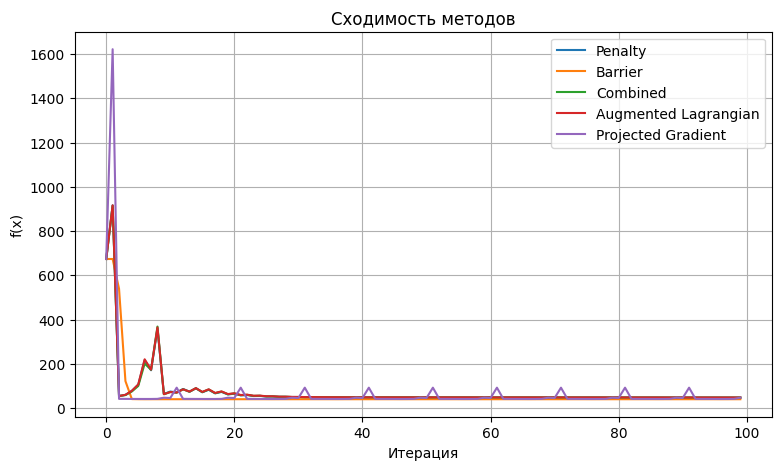

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,5))

max_points = 100

for name, method in methods.items():

    _, history = method(x0)

    values = history["f"][:max_points]

    plt.plot(values, label=name)

plt.xlabel("Итерация")
plt.ylabel("f(x)")
plt.title("Сходимость методов")
plt.legend()
plt.grid()
plt.show()

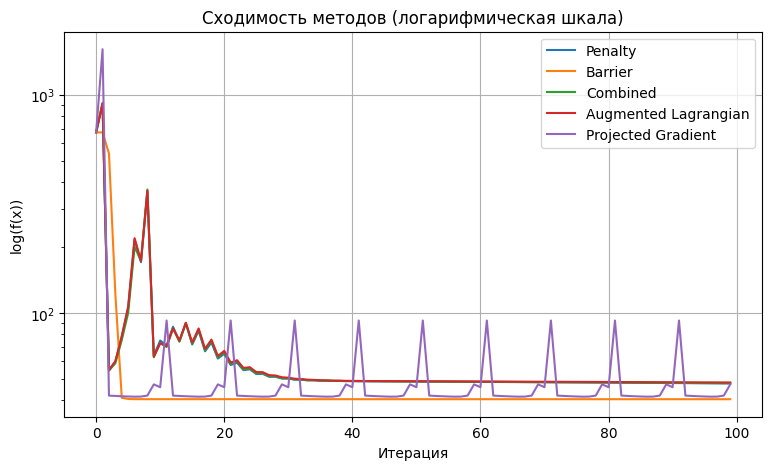

In [11]:
plt.figure(figsize=(9,5))

max_points = 100

for name, method in methods.items():

    _, history = method(x0)

    values = history["f"][:max_points]

    plt.plot(values, label=name)

plt.yscale("log")

plt.xlabel("Итерация")
plt.ylabel("log(f(x))")
plt.title("Сходимость методов (логарифмическая шкала)")
plt.legend()
plt.grid()
plt.show()

# График нормы градиента

Как изменяется градиент по мере выполнения алгоритма

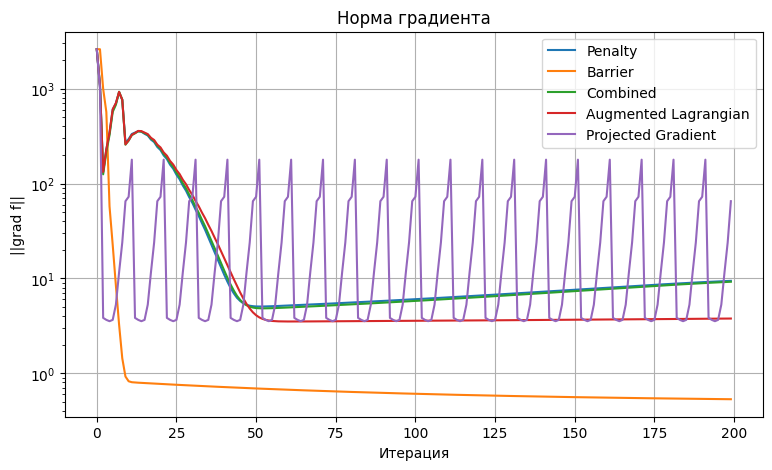

In [12]:
plt.figure(figsize=(9,5))

max_points = 200

for name, method in methods.items():

    _, history = method(x0)

    grads = history["grad_norm"][:max_points]

    plt.plot(grads, label=name)

plt.yscale("log")

plt.xlabel("Итерация")
plt.ylabel("||grad f||")
plt.title("Норма градиента")
plt.legend()
plt.grid()
plt.show()

# Контур функции

In [13]:
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)

X, Y = np.meshgrid(x, y)

Z = a*(X**2 - Y)**2 + b*(X - 1)**2 + f0

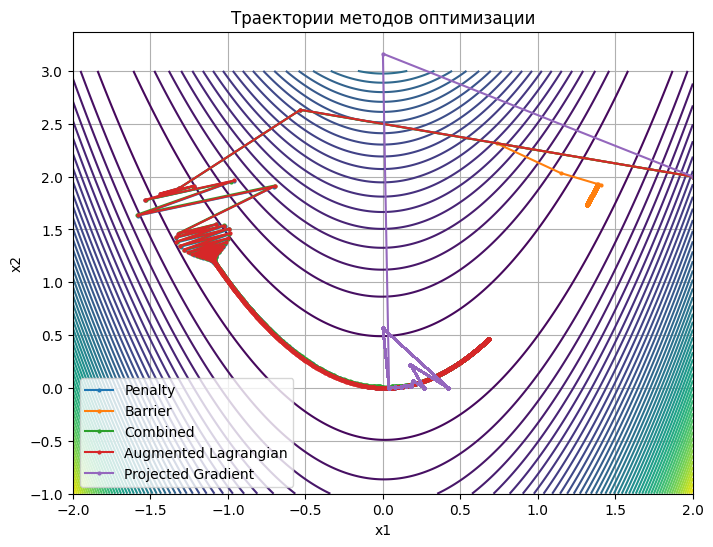

In [14]:
plt.figure(figsize=(8,6))

plt.contour(X, Y, Z, levels=50)

for name, method in methods.items():

    _, history = method(x0)

    path = np.array(history["x"])

    plt.plot(path[:,0], path[:,1], marker='o', markersize=2, label=name)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Траектории методов оптимизации")
plt.legend()
plt.grid()
plt.show()

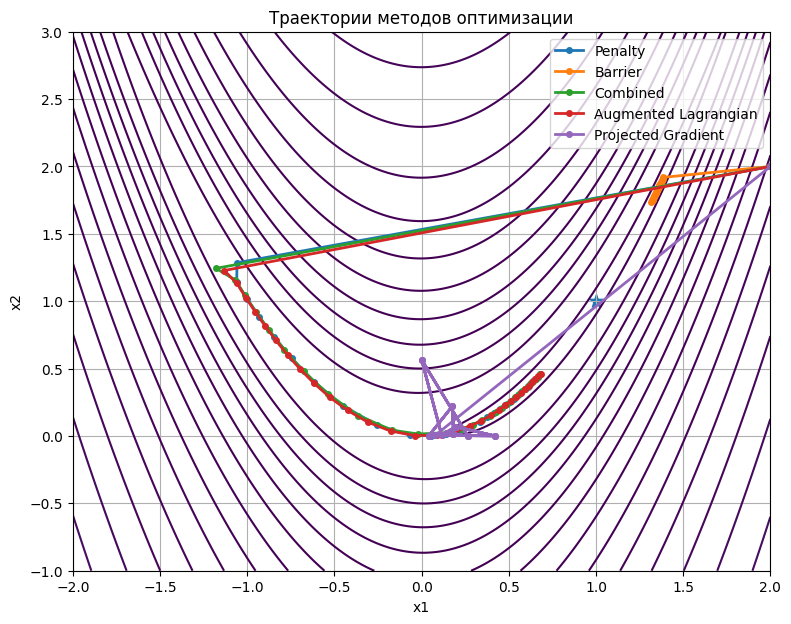

In [23]:
plt.figure(figsize=(9,7))

levels = np.logspace(0, 5, 35)

plt.contour(X, Y, Z, levels=levels)

for name, method in methods.items():

    _, history = method(x0)

    path = np.array(history["x"])

    # прореживание точек
    step = max(1, len(path)//30)

    plt.plot(
        path[::step,0],
        path[::step,1],
        marker='o',
        markersize=4,
        linewidth=2,
        label=name
    )

plt.scatter(1, 1, s=100, marker='*')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Траектории методов оптимизации")
plt.legend()
plt.grid()
plt.show()

# Изменение ошибки по мере сходимости

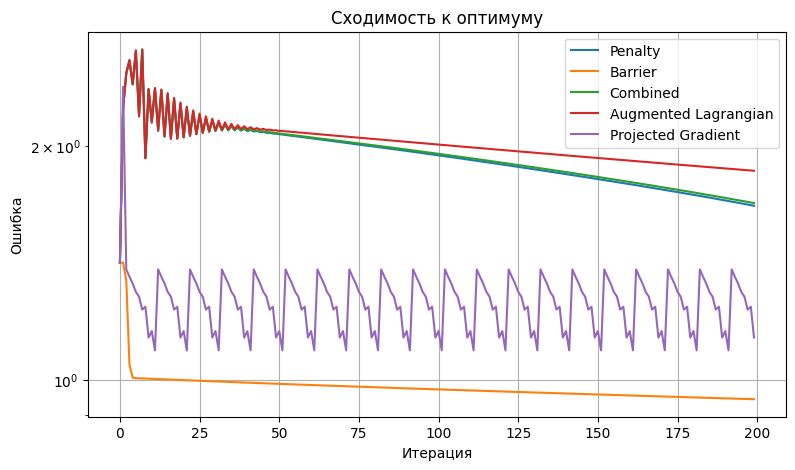

In [16]:
plt.figure(figsize=(9,5))

x_star = np.array([1,1])

for name, method in methods.items():

    _, history = method(x0)

    errors = [
        np.linalg.norm(x - x_star)
        for x in history["x"]
    ]

    plt.plot(errors[:200], label=name)

plt.yscale("log")

plt.xlabel("Итерация")
plt.ylabel("Ошибка")
plt.title("Сходимость к оптимуму")
plt.legend()
plt.grid()
plt.show()

# Сравнение скорости методов

In [17]:
import time
import pandas as pd

EPS = 0.2
TARGET = 40

results = []

for name, method in methods.items():

    start_time = time.time()

    x_res, history = method(x0)

    elapsed = time.time() - start_time

    # ищем первую итерацию достижения точности
    reached_iter = None

    for i, val in enumerate(history["f"]):

        if abs(val - TARGET) <= EPS:
            reached_iter = i
            break

    results.append({
        "Метод": name,
        "Минимум x": np.round(x_res, 4),
        "f(x)": round(f(x_res), 6),
        "Итераций до eps": reached_iter,
        "Всего итераций": len(history["f"]),
        "Время (сек)": round(elapsed, 6)
    })

df_results = pd.DataFrame(results)

print(df_results)

                  Метод         Минимум x       f(x) Итераций до eps  \
0               Penalty  [0.6843, 0.4664]  40.199847            None   
1               Barrier   [1.316, 1.7331]  40.199971            None   
2              Combined  [0.6846, 0.4668]  40.199479            None   
3  Augmented Lagrangian  [0.6845, 0.4666]  40.199687            None   
4    Projected Gradient     [0.4229, 0.0]  45.721797            None   

   Всего итераций  Время (сек)  
0             796     0.016539  
1             804     0.017408  
2             766     0.020763  
3             995     0.007604  
4           10000     0.112782  


# Отладочная информация

In [18]:
for name, method in methods.items():

    _, history = method(x0)

    print(name, len(history["x"]))

Penalty 796
Barrier 804
Combined 766
Augmented Lagrangian 995
Projected Gradient 10000


In [19]:
for name, method in methods.items():

    _, history = method(x0)

    print(name)

    print(history["f"][:10])

    print()

Penalty
[np.float64(674.0), np.float64(916.4887913324068), np.float64(54.84088188408072), np.float64(59.94927109734554), np.float64(78.29130966119449), np.float64(105.68766211764044), np.float64(217.5080228107962), np.float64(171.15398346855065), np.float64(359.4332712348584), np.float64(63.93985734409856)]

Barrier
[np.float64(674.0), np.float64(674.0), np.float64(539.3953713255033), np.float64(122.03053386577847), np.float64(40.890404237463876), np.float64(40.39213688248193), np.float64(40.3135250304527), np.float64(40.30173315708891), np.float64(40.30026085675337), np.float64(40.299717210078335)]

Combined
[np.float64(674.0), np.float64(914.1997465983549), np.float64(54.46141074674354), np.float64(58.94488236326717), np.float64(75.27723015378069), np.float64(100.25546471348258), np.float64(201.3977212912092), np.float64(173.4502544720819), np.float64(368.5737717425532), np.float64(62.71952636569228)]

Augmented Lagrangian
[np.float64(674.0), np.float64(916.4887912750079), np.float64